**Vision Transformer (ViT) for Image Classification**

In [ ]:
# Q1

import os
import zipfile
from PIL import Image
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader

from transformers import AutoImageProcessor

vit_checkpoint = "google/vit-base-patch16-224"
image_processor = AutoImageProcessor.from_pretrained(vit_checkpoint)

print("Loaded image processor from:", vit_checkpoint)
print("Target image size:", image_processor.size)
print("Image mean:", image_processor.image_mean)
print("Image std :", image_processor.image_std)

zip_file_path = "/content/PetImages.zip"
extract_folder = "/content/PetImages_data"


with zipfile.ZipFile(zip_file_path, "r") as zip_ref:
   zip_ref.extractall(extract_folder)


dataset_root = os.path.join(extract_folder, "PetImages")
cat_folder = os.path.join(dataset_root, "Cat")
dog_folder = os.path.join(dataset_root, "Dog")


def collect_valid_images(folder_path, class_label):
    image_rows = []

    for file_name in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file_name)

        if not os.path.isfile(file_path):
            continue

        try:
            with Image.open(file_path) as image_file:
                image_file.convert("RGB")

            image_rows.append({
                "image_path": file_path,
                "label": class_label
            })

        except Exception:
            continue

    return image_rows

cat_rows = collect_valid_images(cat_folder, 0)
dog_rows = collect_valid_images(dog_folder, 1)

all_image_rows = cat_rows + dog_rows

print("\nValid cat images :", len(cat_rows))
print("Valid dog images :", len(dog_rows))
print("Total valid images:", len(all_image_rows))



all_image_paths = [row["image_path"] for row in all_image_rows]
all_labels = [row["label"] for row in all_image_rows]


train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_image_paths,
    all_labels,
    test_size=0.20,
    random_state=42,
    stratify=all_labels
)

validation_paths, test_paths, validation_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

print("\nSplit sizes:")
print("Training   :", len(train_paths))
print("Validation :", len(validation_paths))
print("Test       :", len(test_paths))



class CatsDogsViTDataset(Dataset):
    def __init__(self, image_paths, labels, image_processor):
        self.image_paths = image_paths
        self.labels = labels
        self.image_processor = image_processor

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image_path = self.image_paths[index]
        label = self.labels[index]

        image = Image.open(image_path).convert("RGB")

        processed_image = self.image_processor(
            images=image,
            return_tensors="pt"
        )

        pixel_values = processed_image["pixel_values"].squeeze(0)

        return {
            "pixel_values": pixel_values,
            "labels": torch.tensor(label, dtype=torch.long)
        }


train_dataset = CatsDogsViTDataset(train_paths, train_labels, image_processor)
validation_dataset = CatsDogsViTDataset(validation_paths, validation_labels, image_processor)
test_dataset = CatsDogsViTDataset(test_paths, test_labels, image_processor)



train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)



sample_batch = next(iter(train_loader))

print("\nBatch check:")
print("pixel_values shape:", sample_batch["pixel_values"].shape)
print("labels shape      :", sample_batch["labels"].shape)
print("labels example    :", sample_batch["labels"][:8])

# Label mapping
id_to_label = {0: "cat", 1: "dog"}
label_to_id = {"cat": 0, "dog": 1}

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


Loaded image processor from: google/vit-base-patch16-224
Target image size: {'height': 224, 'width': 224}
Image mean: [0.5, 0.5, 0.5]
Image std : [0.5, 0.5, 0.5]


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))



Valid cat images : 12499
Valid dog images : 12499
Total valid images: 24998

Split sizes:
Training   : 19998
Validation : 2500
Test       : 2500

Batch check:
pixel_values shape: torch.Size([16, 3, 224, 224])
labels shape      : torch.Size([16])
labels example    : tensor([0, 1, 0, 0, 0, 1, 0, 1])


In [ ]:
import torch
from transformers import ViTForImageClassification


id_to_label = {0: "cat", 1: "dog"}
label_to_id = {"cat": 0, "dog": 1}


In [ ]:
vit_model = ViTForImageClassification.from_pretrained(
    vit_checkpoint,
    num_labels=2,
    id2label=id_to_label,
    label2id=label_to_id,
    ignore_mismatched_sizes=True
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vit_model.to(device)



model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [ ]:
print("\nClassifier layer:")
print(vit_model.classifier)


Classifier layer:
Linear(in_features=768, out_features=2, bias=True)


In [ ]:
import torch
import torch.nn as nn
from torch.optim import AdamW

epoch_count = 3
learning_rate = 2e-5


loss_function = nn.CrossEntropyLoss()

optimizer = AdamW(vit_model.parameters(), lr=learning_rate)

print("Training setup is ready.")
print("Epochs        :", epoch_count)
print("Learning rate :", learning_rate)

Training setup is ready.
Epochs        : 3
Learning rate : 2e-05


In [ ]:
def train_one_epoch(model, data_loader, optimizer, loss_function, device):
    model.train()

    total_loss = 0
    total_correct = 0
    total_samples = 0

    for batch in data_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(pixel_values=pixel_values)
        logits = outputs.logits

        loss = loss_function(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        predictions = torch.argmax(logits, dim=1)
        total_correct += (predictions == labels).sum().item()
        total_samples += labels.size(0)

    average_loss = total_loss / len(data_loader)
    accuracy = total_correct / total_samples

    return average_loss, accuracy


def evaluate_one_epoch(model, data_loader, loss_function, device):
    model.eval()

    total_loss = 0
    total_correct = 0
    total_samples = 0

    all_predictions = []
    all_true_labels = []

    with torch.no_grad():
        for batch in data_loader:
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(pixel_values=pixel_values)
            logits = outputs.logits

            loss = loss_function(logits, labels)
            total_loss += loss.item()

            predictions = torch.argmax(logits, dim=1)

            total_correct += (predictions == labels).sum().item()
            total_samples += labels.size(0)

            all_predictions.extend(predictions.cpu().numpy())
            all_true_labels.extend(labels.cpu().numpy())

    average_loss = total_loss / len(data_loader)
    accuracy = total_correct / total_samples

    return average_loss, accuracy, all_predictions, all_true_labels

In [ ]:
train_loss_history = []
train_accuracy_history = []

validation_loss_history = []
validation_accuracy_history = []

best_validation_accuracy = 0
best_model_path = "best_vit_cats_dogs.pt"

for epoch_index in range(epoch_count):
    print(f"\nEpoch {epoch_index + 1}/{epoch_count}")

    train_loss, train_accuracy = train_one_epoch(
        model=vit_model,
        data_loader=train_loader,
        optimizer=optimizer,
        loss_function=loss_function,
        device=device
    )

    validation_loss, validation_accuracy, _, _ = evaluate_one_epoch(
        model=vit_model,
        data_loader=validation_loader,
        loss_function=loss_function,
        device=device
    )

    train_loss_history.append(train_loss)
    train_accuracy_history.append(train_accuracy)

    validation_loss_history.append(validation_loss)
    validation_accuracy_history.append(validation_accuracy)

    print(f"Training Loss      : {train_loss:.4f}")
    print(f"Training Accuracy  : {train_accuracy:.4f}")
    print(f"Validation Loss    : {validation_loss:.4f}")
    print(f"Validation Accuracy: {validation_accuracy:.4f}")

    if validation_accuracy > best_validation_accuracy:
        best_validation_accuracy = validation_accuracy
        torch.save(vit_model.state_dict(), best_model_path)



Epoch 1/3


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Training Loss      : 0.0287
Training Accuracy  : 0.9902
Validation Loss    : 0.0142
Validation Accuracy: 0.9936

Epoch 2/3
Training Loss      : 0.0034
Training Accuracy  : 0.9992
Validation Loss    : 0.0110
Validation Accuracy: 0.9972

Epoch 3/3
Training Loss      : 0.0056
Training Accuracy  : 0.9982
Validation Loss    : 0.0129
Validation Accuracy: 0.9956


In [ ]:
vit_model.load_state_dict(torch.load(best_model_path))
vit_model.to(device)

test_loss, test_accuracy, test_predictions, test_true_labels = evaluate_one_epoch(
    model=vit_model,
    data_loader=test_loader,
    loss_function=loss_function,
    device=device
)

print("\nTest Results")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")


Test Results
Test Loss     : 0.0083
Test Accuracy : 0.9960


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

report = classification_report(
    test_true_labels,
    test_predictions,
    target_names=["cat", "dog"]
)

print("\nClassification Report:\n")
print(report)

conf_matrix = confusion_matrix(test_true_labels, test_predictions)

conf_matrix_frame = pd.DataFrame(
    conf_matrix,
    index=["Actual Cat", "Actual Dog"],
    columns=["Predicted Cat", "Predicted Dog"]
)

print("\nConfusion Matrix:\n")
print(conf_matrix_frame)


Classification Report:

              precision    recall  f1-score   support

         cat       0.99      1.00      1.00      1250
         dog       1.00      0.99      1.00      1250

    accuracy                           1.00      2500
   macro avg       1.00      1.00      1.00      2500
weighted avg       1.00      1.00      1.00      2500


Confusion Matrix:

            Predicted Cat  Predicted Dog
Actual Cat           1247              3
Actual Dog              7           1243


In [ ]:
from google.colab import files

files.download(best_model_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

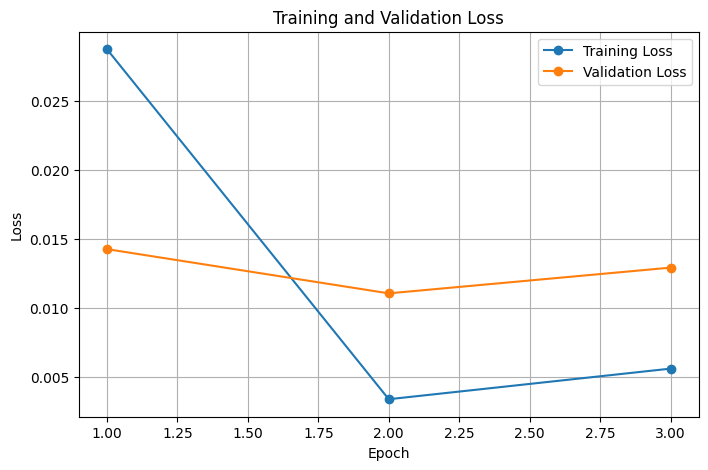

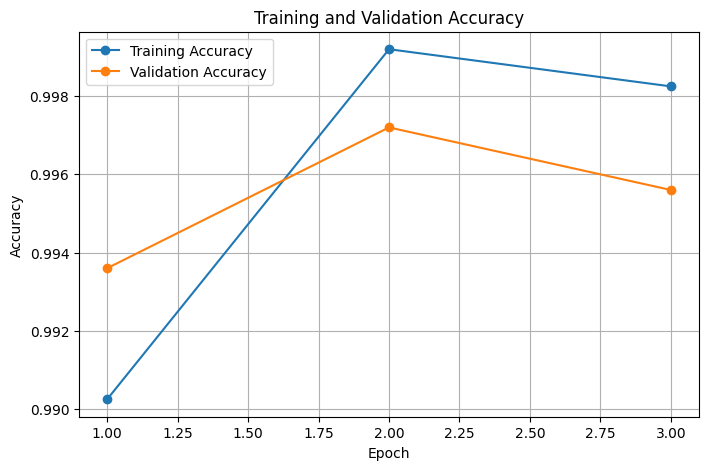

In [ ]:
import matplotlib.pyplot as plt

epoch_numbers = list(range(1, epoch_count + 1))


plt.figure(figsize=(8, 5))
plt.plot(epoch_numbers, train_loss_history, marker="o", label="Training Loss")
plt.plot(epoch_numbers, validation_loss_history, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epoch_numbers, train_accuracy_history, marker="o", label="Training Accuracy")
plt.plot(epoch_numbers, validation_accuracy_history, marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# **References:**



*   Pytorch tutorials - https://pytorch.org/tutorials/beginner/deep_learning_60min_blitz.html

*   Matplotlib - https://matplotlib.org/stable/index.html


*   Python Docs - https://docs.python.org/3/library/time.html



*   Sci-kit learn documentation- https://scikit-learn.org/0.21/documentation.html


*   Pandas documentation- https://pandas.pydata.org/docs/


*   Dataset used - https://www.microsoft.com/en-us/download/details.aspx?id=54765




*   Tokenizer - https://pytorch.org/text/stable/data_utils.html

*    Tokenizer - https://pytorch.org/text/stable/data_utils.html

